<a href="https://colab.research.google.com/github/abdullah-and-ai/Stock-analysis-demo/blob/main/Stock_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

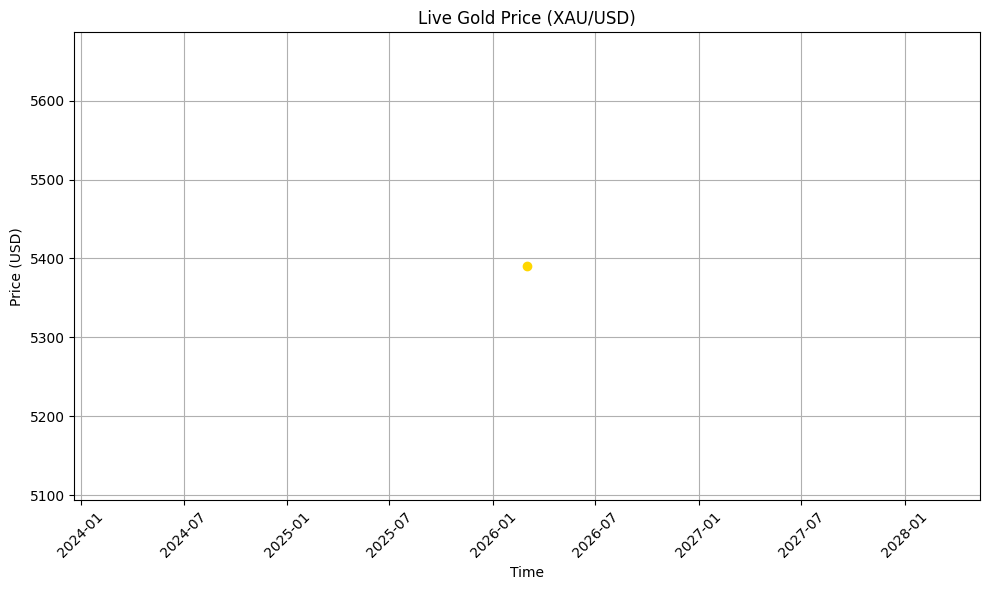

Live Gold Price: 5390.15651 at 2026-03-02 11:04:51

Live feed stopped by user.


In [ ]:
import requests
import time
import matplotlib.pyplot as plt
import IPython.display as display
from datetime import datetime

API_KEY = # <-- paste api key , in my case i used twelve data api key
URL = f"https://api.twelvedata.com/price?symbol=XAU/USD&apikey={API_KEY}"

print("Starting live gold price feed with live graph...\n")
timestamps = []
prices = []
plt.figure(figsize=(10, 6))
plt.ion()

try:
    while True:
        response = requests.get(URL).json()

        if "price" in response:
            price = float(response["price"])
            current_time = datetime.now()

            timestamps.append(current_time)
            prices.append(price)
            display.clear_output(wait=True)
            plt.clf()
            plt.plot(timestamps, prices, marker='o', linestyle='-', color='gold')
            plt.title('Live Gold Price (XAU/USD)')
            plt.xlabel('Time')
            plt.ylabel('Price (USD)')
            plt.grid(True)
            plt.xticks(rotation=45)
            plt.tight_layout()
            display.display(plt.gcf())

            print(f"Live Gold Price: {price} at {current_time.strftime('%Y-%m-%d %H:%M:%S')}") # Still print to console

        else:
            print("API Error:", response)

        time.sleep(60)   # 60 sec wait bcz api manage 8 request per minute , but 1 per minture is safe

except KeyboardInterrupt:
    print("\nLive feed stopped by user.")
except Exception as e:
    print("Error:", e)
finally:
    plt.ioff()
    plt.close()
